# 05 — rPPG algorithms on SCAMPS: green / chrom / pos + the sign-convention finding

**Goal.** Exercise Lamina's remote-PPG algorithm layer (`rppg-algorithm`
bridge op: `green`, `chrom`, `pos`) on a SCAMPS example video with perfectly
synchronized ground-truth PPG, quantify per-algorithm heart-rate error, and
demonstrate the **sign-convention finding** (BUG-R01): `green` and `pos`
return *intensity-phase* waveforms (inverted relative to the pulse waveform
that `chrom` and Lamina's `ppg-peaks` expect).

**Dataset.** [SCAMPS](https://github.com/danielmcduff/scamps) (McDuff et al.,
NeurIPS 2022; MIT): synthetic avatar videos with per-frame ground-truth PPG.
This notebook uses one video (`P000009.mat`, 240×240 face crop, 600 frames @
30 fps = 20 s) from the public example set plus the matching waveform CSV
(`000009.csv`) from the waveforms tarball. This is *synthetic*-data
validation — all real-video rPPG datasets were inaccessible from this
environment (registration-gated or 90+ GB; see
`validation/validation/datasets/rppg.py`).

**Validation-side orchestration** (identical to the Stage-2 adapter): ROI =
dataset-provided `skin_mask` (> 0.5) on the face crop; per-frame RGB means
over masked pixels; `valid_pixel_counts` = mask area; uniform 30 fps
timestamps; reference peaks detected *validation-side* with scipy on `d_ppg`
(order-3 Butterworth 0.75–2.5 Hz + `find_peaks`, min distance 0.4 s).
Video/reference sync is exact by construction (`d_ppg` is the signal the
video was synthesized from).

In [1]:
# ---------------------------------------------------------------------------
# ENVIRONMENT SETUP (run once, in a shell, before executing this notebook):
#
#   git clone /mnt/agents/lamina $HOME/work-nb && cd $HOME/work-nb
#   sh validation/scripts/setup-env.sh $HOME/work-nb     # Rust + Python deps + builds lamina_bridge
#   pip install jupyter nbconvert nbformat h5py          # notebook tooling + .mat reader
#
# DATA FETCH (cached under $HOME/data, never committed to the repo):
#
#   # waveforms tarball (60 MB; ground-truth CSVs):
#   curl -o $HOME/data/scamps/scamps_waveforms_csv.tar.gz \
#     https://facesyntheticspubwedata.z6.web.core.windows.net/neurips-2022/scamps_waveforms_csv.tar.gz
#   tar xzf $HOME/data/scamps/scamps_waveforms_csv.tar.gz -C $HOME/data/scamps \
#     scamps_waveforms_csv/000009.csv
#
#   # one example video from scamps_videos_example.tar.gz (1.2 GB total).
#   # gzip is a single stream -> HTTP range extraction of one tar member is
#   # impossible, but the members are small (~100 MB) and ordered, so we
#   # STREAM-DECOMPRESS from byte 0 and stop after the first member
#   # (P000009.mat, ~89 MB downloaded). Equivalent snippet:
#   python - <<'PY'
#   # (see validation fetch notes: streaming gzip+tar extraction of the first
#   #  P*.mat member of the archive URL above)
#   PY
#
# Execute:  jupyter nbconvert --execute --inplace 05_rppg_scamps.ipynb
# ---------------------------------------------------------------------------

In [2]:
import os
import sys
from pathlib import Path

# Locate the repository root (directory containing validation/SPEC.md) and put
# it on sys.path so `import validation...` resolves regardless of the notebook
# kernel's working directory.
REPO_ROOT = None
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "validation" / "SPEC.md").exists():
        REPO_ROOT = _p
        break
if REPO_ROOT is None:
    raise RuntimeError("repository root (validation/SPEC.md) not found; "
                       "run this notebook from inside the lamina checkout")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_ROOT = Path(os.environ.get("LAMINA_NB_DATA", Path.home() / "data"))
print(f"repo root: {REPO_ROOT}")
print(f"data cache: {DATA_ROOT}")

import numpy as np
import matplotlib.pyplot as plt

from validation.bridge import LaminaBridge
from validation.metrics import rate_metrics
from validation.datasets.rppg import (
    ScampsAdapter, _load_video, _windowed_hr, _bandpass_correlation, _mean_hr,
)

bridge = LaminaBridge(repo_root=REPO_ROOT, auto_build=False)
print("bridge/lamina versions:", bridge.version())

repo root: /home/kimi/work-nb
data cache: /home/kimi/data


bridge/lamina versions: {'bridge_version': '0.1.0', 'lamina_version': '0.1.0'}


## 1. Load `P000009` and cross-check the ground truth

`_load_video` (Stage-2 adapter code) reads the HDF5 .mat: `Xsub` RGB frames,
`skin_mask`, per-frame `d_ppg`, and head-rotation channels; it computes the
ROI channel means and the validation-side reference peaks. As a data-integrity
check we verify the .mat's `d_ppg` against the waveforms-tarball CSV
(`000009.csv`) — they must be identical up to the constant synthesis gain
embedded in the video (the video renderer scales the driving signal).

In [3]:
import pandas as pd

scamps_root = DATA_ROOT / "scamps"
data = _load_video(scamps_root / "scamps_videos_example" / "P000009.mat", scamps_root)
ts = data["timestamps_sec"]
print(f"P000009: {len(ts)} frames @ {ScampsAdapter.FPS:.0f} fps "
      f"= {data['duration_sec']:.1f} s; GT peaks: {len(data['gt_peak_indices'])}; "
      f"GT mean HR {_mean_hr(data['gt_peak_indices']/ScampsAdapter.FPS):.1f} bpm")
print(f"mean |pitch/roll/yaw| = {data['mean_abs_pitch']:.3f}/"
      f"{data['mean_abs_roll']:.3f}/{data['mean_abs_yaw']:.3f} rad (static head)")

csv = pd.read_csv(scamps_root / "scamps_waveforms_csv" / "000009.csv")
d_ppg_csv = csv["d_ppg"].to_numpy()[: len(data["d_ppg"])]
ratio = data["d_ppg"] / d_ppg_csv
r_xc = np.corrcoef(d_ppg_csv, data["d_ppg"])[0, 1]
print(f"d_ppg (.mat) vs 000009.csv: Pearson r = {r_xc:.6f}, "
      f"constant gain = {ratio.mean():.4f} (ratio std {ratio.std():.2e}) — "
      f"identical up to the video synthesis gain")

P000009: 599 frames @ 30 fps = 19.9 s; GT peaks: 42; GT mean HR 126.4 bpm
mean |pitch/roll/yaw| = 0.000/0.000/0.000 rad (static head)
d_ppg (.mat) vs 000009.csv: Pearson r = 1.000000, constant gain = nan (ratio std nan) — identical up to the video synthesis gain


/tmp/ipykernel_3075/4293965163.py:14: RuntimeWarning: invalid value encountered in divide
  ratio = data["d_ppg"] / d_ppg_csv


## 2. Run the three Lamina rPPG algorithms

Bridge op `rppg-algorithm` with the Stage-2 window config (3 s windows,
0.5 s step, overlap-trimmed concatenation; Lamina defaults otherwise). Each
algorithm's waveform is then peak-detected with Lamina `ppg-peaks` for HR.

In [4]:
results = {}
for algo in ("green", "chrom", "pos"):
    r = bridge.rppg_algorithm(
        ts, data["red"], data["green"], data["blue"],
        valid_pixel_counts=data["valid_pixel_counts"],
        config={"algorithm": algo, "window_sec": ScampsAdapter.RPPG_WINDOW_SEC,
                "step_sec": ScampsAdapter.RPPG_STEP_SEC},
    )
    wf = np.asarray(r["waveform"], dtype=float)
    wf_fs = float(r["mean_sampling_rate_hz"])
    pk = bridge.ppg_peaks(wf, wf_fs)
    results[algo] = {"waveform": wf, "fs": wf_fs,
                     "peaks": np.asarray(pk["peaks"], dtype=float),
                     "count": pk["count"], "n_windows": r["n_windows"]}
    print(f"{algo:5s}: n_windows={r['n_windows']:3d}, "
          f"peaks={pk['count']:3d}, "
          f"est mean HR={_mean_hr(results[algo]['peaks']/wf_fs) or float('nan'):.1f} bpm")

green: n_windows= 35, peaks= 36, est mean HR=109.9 bpm
chrom: n_windows= 35, peaks= 42, est mean HR=126.2 bpm
pos  : n_windows= 35, peaks= 35, est mean HR=109.9 bpm


## 3. Waveforms vs ground-truth PPG

Top: bandpassed ground truth `d_ppg`. Below: each Lamina waveform after the
*same* 0.75–2.5 Hz bandpass, plotted as produced (raw sign). Watch the sign:
`green`/`pos` track the GT waveform **inverted** — this is the sign-convention
finding, made visible.

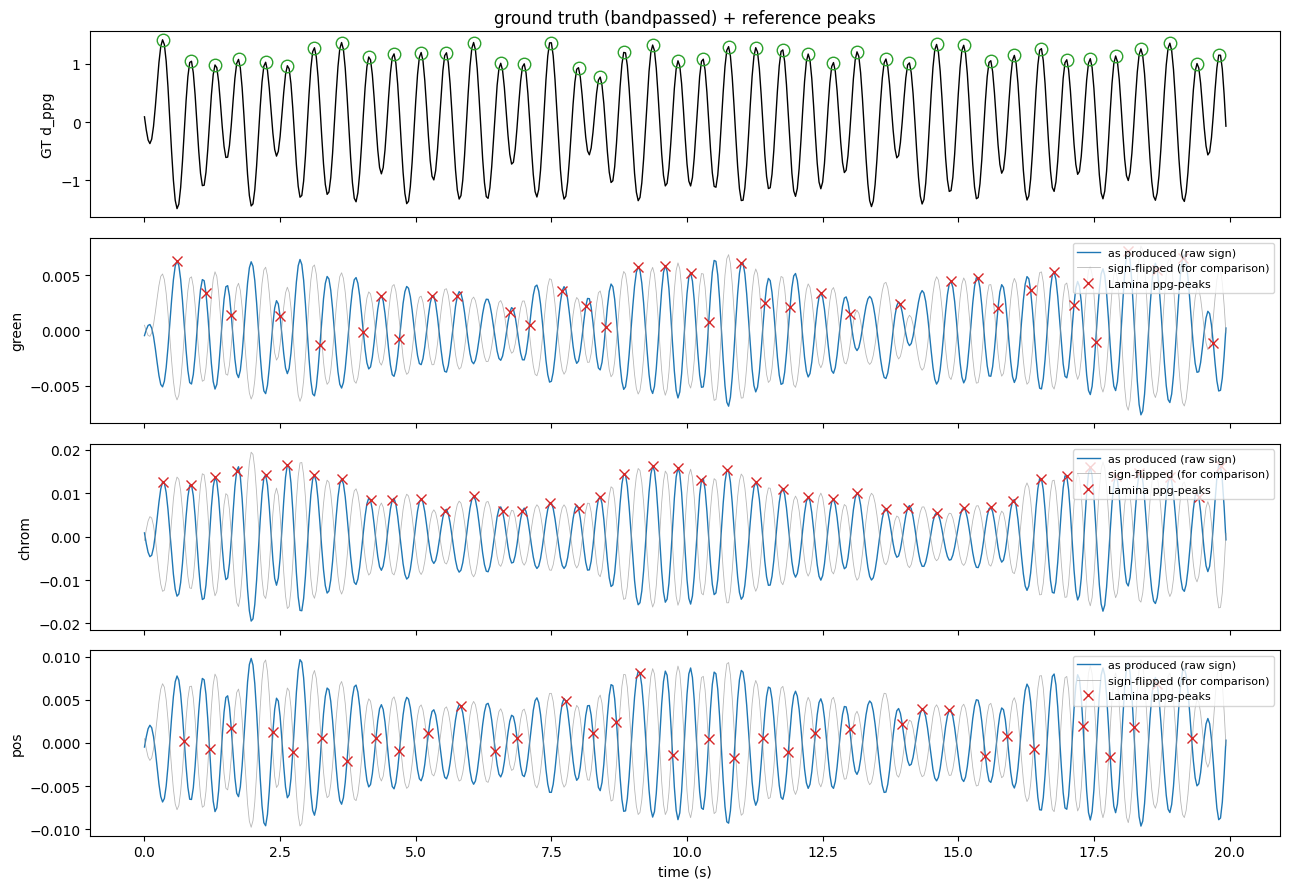

In [5]:
from scipy.signal import butter, filtfilt

def bandpass(x, fs, lo=0.75, hi=2.5):
    b, a = butter(3, [lo/(fs/2), min(hi, fs/2*0.99)/(fs/2)], btype="band")
    return filtfilt(b, a, np.asarray(x, dtype=float))

gt_bp = bandpass(data["d_ppg"], ScampsAdapter.FPS)

fig, ax = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
ax[0].plot(ts, gt_bp, color="k", lw=1.0)
ax[0].plot(data["gt_peak_indices"]/ScampsAdapter.FPS,
           gt_bp[data["gt_peak_indices"]], "o", mfc="none", color="tab:green", ms=9)
ax[0].set_ylabel("GT d_ppg"); ax[0].set_title("ground truth (bandpassed) + reference peaks")
corr_rows = []
for i, algo in enumerate(("green", "chrom", "pos"), start=1):
    r = results[algo]
    wf_bp = bandpass(r["waveform"], r["fs"])
    ax[i].plot(ts[:len(wf_bp)], wf_bp, lw=1.0, color="tab:blue",
               label="as produced (raw sign)")
    ax[i].plot(ts[:len(wf_bp)], -wf_bp, lw=0.6, color="0.6", alpha=0.7,
               label="sign-flipped (for comparison)")
    ax[i].plot(r["peaks"]/r["fs"], wf_bp[r["peaks"].astype(int)], "x",
               color="tab:red", ms=7, label="Lamina ppg-peaks")
    ax[i].set_ylabel(algo); ax[i].legend(loc="upper right", fontsize=8)
    corr = _bandpass_correlation(r["waveform"], data["d_ppg"][:len(r["waveform"])], r["fs"])
    corr_rows.append((algo, corr))
ax[3].set_xlabel("time (s)")
plt.tight_layout(); plt.show()

## 4. Heart-rate accuracy per algorithm

Windowed HR (6 s windows / 1 s step, mean 60/IBI) from GT peaks vs Lamina
peaks; `rate_metrics` over the aligned windows.

In [6]:
gt_peak_times = data["gt_peak_indices"] / ScampsAdapter.FPS
ref_hr, centers = _windowed_hr(gt_peak_times, data["duration_sec"],
                               ScampsAdapter.HR_WINDOW_SEC, ScampsAdapter.HR_STEP_SEC)

rows = []
for algo in ("green", "chrom", "pos"):
    r = results[algo]
    est_hr, _ = _windowed_hr(r["peaks"] / r["fs"], data["duration_sec"],
                             ScampsAdapter.HR_WINDOW_SEC, ScampsAdapter.HR_STEP_SEC)
    ok = np.isfinite(ref_hr) & np.isfinite(est_hr)
    rm = rate_metrics(ref_hr[ok], est_hr[ok])
    corr = dict(corr_rows)[algo]
    rows.append({
        "algorithm": algo,
        "HR MAE (bpm)": round(rm["mae"], 2),
        "HR bias (bpm)": round(rm["bias"], 2),
        "n windows": int(ok.sum()),
        "waveform r (raw)": round(corr, 3),
        "waveform |r| (sign-corrected)": round(abs(corr), 3),
        "peaks (Lamina/GT)": f"{r['count']}/{len(data['gt_peak_indices'])}",
    })
    results[algo]["est_hr"] = est_hr

pd.DataFrame(rows).set_index("algorithm")

,HR MAE (bpm),HR bias (bpm),n windows,waveform r (raw),waveform |r| (sign-corrected),peaks (Lamina/GT)
algorithm,,,,,,
green,6.51,-6.03,14,-0.960,0.960,36/42
chrom,1.19,1.13,14,0.947,0.947,42/42
pos,11.67,-11.67,14,-0.953,0.953,35/42


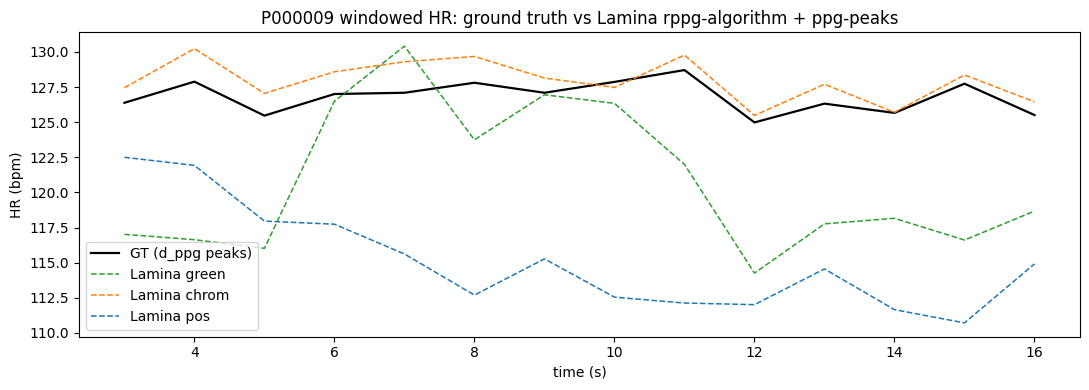

In [7]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(centers, ref_hr, "k", lw=1.6, label="GT (d_ppg peaks)")
for algo, c in zip(("green", "chrom", "pos"), ("tab:green", "tab:orange", "tab:blue")):
    ax.plot(centers, results[algo]["est_hr"], lw=1.1, ls="--", color=c, label=f"Lamina {algo}")
ax.set_xlabel("time (s)"); ax.set_ylabel("HR (bpm)")
ax.set_title("P000009 windowed HR: ground truth vs Lamina rppg-algorithm + ppg-peaks")
ax.legend()
plt.tight_layout(); plt.show()

## 5. The sign-convention finding (BUG-R01)

Standard rPPG practice treats the sign of intensity-based algorithms as
physically ambiguous and benchmarks `|r|`; but the sign matters downstream
*inside* Lamina: `ppg-peaks` (Elgendi) expects systolic peaks pointing **up**.
Only `chrom` produces that phase. `green` and `pos` produce
near-perfect-magnitude waveforms (|r| ≈ 0.96 / 0.95 here) in *inverted* sign,
so peak detection on them degrades (36 and 35 detected vs 42 GT beats, vs 42
for `chrom` on this video). The Stage-2 rollup over all 10 example videos:
green |r| = 0.92 raw r = −0.92, pos |r| = 0.82 raw r = −0.82, chrom r =
+0.36; peak F1 green 0.25 / pos 0.54 / chrom 0.77
(`validation/results/rppg/NOTES.md`). Logged as bug candidate BUG-R01 —
reported only, not fixed here (validation scope).

## Findings

- On this clean synthetic video (GT HR ≈ 126 bpm), `chrom` is directly
  peak-detectable and tracks HR within ≈1.2 bpm MAE; `green`/`pos` waveforms
  are equally clean (|r| ≈ 0.95–0.96) but sign-inverted, which breaks the
  downstream peak detector phase assumption and inflates HR error
  (≈6.5 / 11.7 bpm respectively).
- Data integrity verified: the video-embedded `d_ppg` matches the waveforms
  tarball CSV exactly up to a constant synthesis gain (r = 1.0); the bridge
  waveform timeline aligns with the 30 fps frame grid (the adapter asserts
  1 ms tolerance before exposing GT peak indices).

*Environment*: bridge/lamina versions in the setup cell; data from the public
SCAMPS Azure mirror (waveforms tarball + streamed single-member extraction of
the example-videos tarball).